# Solar Cycle Peak Forecasting — Phase 1: Monthly Sunspot Forecasting

**Goal:** Predict `SN(t+1)` — next month's sunspot number — from historical features.  
**Models:** Persistence · Moving Average · Linear Regression · Random Forest · XGBoost  
**Validation:** Strict time-ordered split — no shuffling, no future leakage


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    print("XGBoost not found — install with: pip install xgboost")
    HAS_XGB = False

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

RANDOM_STATE = 42
print("Imports OK | XGBoost:", HAS_XGB)


Imports OK | XGBoost: True


## Load Phase 0 Output

In [9]:
df = pd.read_csv("SN_monthly_clean.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df["SN_clean"] = df["SN_clean"].ffill()

print(f"Shape : {df.shape}")
print(f"Period: {df['Date'].iloc[0].date()} → {df['Date'].iloc[-1].date()}")
print(f"NaN remaining: {df['SN_clean'].isna().sum()}")
df[["Date","SN","SN_clean"]].head(6)

Shape : (3329, 8)
Period: 1749-01-01 → 2026-05-01
NaN remaining: 0


,Date,SN,SN_clean
0,1749-01-01,96.7,96.7
1,1749-02-01,104.3,104.3
2,1749-03-01,116.7,116.7
3,1749-04-01,92.8,92.8
4,1749-05-01,141.7,141.7
5,1749-06-01,139.2,139.2


## Step 1.1–1.3 · Feature Engineering

In [10]:
def make_slope(series, window):
    """Rolling OLS slope over `window` months."""
    slopes = np.full(len(series), np.nan)
    x = np.arange(window, dtype=float)
    x_mean = x.mean()
    denom = ((x - x_mean) ** 2).sum()
    arr = series.values
    for i in range(window - 1, len(arr)):
        y = arr[i - window + 1 : i + 1]
        if np.isnan(y).any():
            continue
        y_mean = y.mean()
        slopes[i] = ((x - x_mean) * (y - y_mean)).sum() / denom
    return slopes

sn = df["SN_clean"].copy()

# 1.1 Lag features
for lag in [1, 3, 6, 12, 24, 36]:
    df[f"lag{lag}"] = sn.shift(lag)

# 1.2 Rolling mean features
for w in [3, 6, 12, 24]:
    df[f"rolling_mean_{w}"] = sn.shift(1).rolling(w).mean()

# 1.3 Trend / slope features
for w in [3, 6, 12]:
    df[f"slope_{w}"] = make_slope(sn.shift(1).bfill(), w)
    

# Calendar features (helps capture solar-cycle seasonality at multi-year scale)
df["month_sin"] = np.sin(2 * np.pi * df["Date"].dt.month / 12)
df["month_cos"] = np.cos(2 * np.pi * df["Date"].dt.month / 12)

feature_cols = (
    [f"lag{l}" for l in [1,3,6,12,24,36]] +
    [f"rolling_mean_{w}" for w in [3,6,12,24]] +
    [f"slope_{w}" for w in [3,6,12]] +
    ["month_sin", "month_cos"]
)

print(f"Features ({len(feature_cols)}): {feature_cols}")
df[feature_cols].describe().round(2)


Features (15): ['lag1', 'lag3', 'lag6', 'lag12', 'lag24', 'lag36', 'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12', 'rolling_mean_24', 'slope_3', 'slope_6', 'slope_12', 'month_sin', 'month_cos']


,lag1,lag3,lag6,lag12,lag24,lag36,rolling_mean_3,rolling_mean_6,rolling_mean_12,rolling_mean_24,slope_3,slope_6,slope_12,month_sin,month_cos
count,3328.00,3326.00,3323.00,3317.00,3305.00,3293.00,3326.00,3323.00,3317.00,3305.00,3327.00,3324.00,3318.00,3329.00,3329.00
mean,82.20,82.19,82.17,82.11,81.85,81.68,82.19,82.17,82.10,81.90,-0.00,-0.00,-0.00,0.00,-0.00
std,67.61,67.63,67.65,67.69,67.65,67.70,65.50,64.39,63.06,60.09,16.16,7.37,4.11,0.71,0.71
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.06,-80.15,-31.60,-12.29,-1.00,-1.00
25%,24.38,24.32,24.30,24.20,24.10,24.00,24.41,24.66,25.67,29.34,-8.15,-3.93,-2.42,-0.50,-0.50
50%,68.50,68.45,68.40,68.30,67.80,67.50,70.22,71.13,72.68,71.64,-0.10,-0.01,-0.38,0.00,0.00
75%,123.05,123.15,123.10,123.00,122.50,122.40,121.52,120.49,121.10,120.03,7.88,3.76,2.13,0.87,0.50
max,398.20,398.20,398.20,398.20,398.20,398.20,332.33,308.55,287.04,270.63,90.55,39.99,18.78,1.00,1.00


## Step 1.4–1.5 · Dataset Construction & Split

In [11]:
# Target: SN one month ahead
df["target"] = sn.shift(-1)

# Drop rows with NaN in features or target
model_df = df[["Date"] + feature_cols + ["target"]].dropna().copy()
model_df = model_df.reset_index(drop=True)

print(f"Model-ready rows: {len(model_df)}")
print(f"Period: {model_df['Date'].iloc[0].date()} → {model_df['Date'].iloc[-1].date()}")

# ── Strict time-ordered split ──────────────────────────────────────────────────
train_mask = model_df["Date"] <= "2000-12-01"
val_mask   = (model_df["Date"] >= "2001-01-01") & (model_df["Date"] <= "2015-12-01")
test_mask  = model_df["Date"] >= "2016-01-01"

X_train = model_df.loc[train_mask, feature_cols].values
y_train = model_df.loc[train_mask, "target"].values

X_val   = model_df.loc[val_mask, feature_cols].values
y_val   = model_df.loc[val_mask, "target"].values

X_test  = model_df.loc[test_mask, feature_cols].values
y_test  = model_df.loc[test_mask, "target"].values

print(f"\nTrain : {X_train.shape[0]:4d} rows  ({model_df.loc[train_mask,'Date'].iloc[0].date()} → {model_df.loc[train_mask,'Date'].iloc[-1].date()})")
print(f"Val   : {X_val.shape[0]:4d} rows  ({model_df.loc[val_mask,'Date'].iloc[0].date()} → {model_df.loc[val_mask,'Date'].iloc[-1].date()})")
print(f"Test  : {X_test.shape[0]:4d} rows  ({model_df.loc[test_mask,'Date'].iloc[0].date()} → {model_df.loc[test_mask,'Date'].iloc[-1].date()})")


Model-ready rows: 3292
Period: 1752-01-01 → 2026-04-01

Train : 2988 rows  (1752-01-01 → 2000-12-01)
Val   :  180 rows  (2001-01-01 → 2015-12-01)
Test  :  124 rows  (2016-01-01 → 2026-04-01)


In [12]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {"Model": name, "MAE": round(mae,2), "RMSE": round(rmse,2), "R2": round(r2,4)}

results = []   # collect all evaluation dicts
preds   = {}   # store (y_true, y_pred) for plotting


## Step 1.6 · Baselines

In [13]:
# ── Persistence: predict SN(t+1) = SN(t) ─────────────────────────────────────
# lag1 IS SN(t), so just use that column directly
lag1_idx = feature_cols.index("lag1")

pers_val_pred  = X_val[:, lag1_idx]
pers_test_pred = X_test[:, lag1_idx]

results.append(evaluate("Persistence (val)",  y_val,  pers_val_pred))
results.append(evaluate("Persistence (test)", y_test, pers_test_pred))
preds["Persistence"] = (y_test, pers_test_pred)
print("Persistence done")

# ── Moving Average (12-month) ─────────────────────────────────────────────────
rm12_idx = feature_cols.index("rolling_mean_12")

ma_val_pred  = X_val[:, rm12_idx]
ma_test_pred = X_test[:, rm12_idx]

results.append(evaluate("MovingAvg-12 (val)",  y_val,  ma_val_pred))
results.append(evaluate("MovingAvg-12 (test)", y_test, ma_test_pred))
preds["MovingAvg-12"] = (y_test, ma_test_pred)
print("Moving Average done")

# ── Linear Regression ─────────────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_val_pred  = lr.predict(X_val)
lr_test_pred = lr.predict(X_test)

results.append(evaluate("LinearRegression (val)",  y_val,  lr_val_pred))
results.append(evaluate("LinearRegression (test)", y_test, lr_test_pred))
preds["LinearRegression"] = (y_test, lr_test_pred)
print("Linear Regression done")

pd.DataFrame([r for r in results]).style.format({"MAE":"{:.2f}","RMSE":"{:.2f}","R2":"{:.4f}"})


Persistence done
Moving Average done
Linear Regression done


,Model,MAE,RMSE,R2
0,Persistence (val),18.69,25.42,0.7774
1,Persistence (test),15.05,21.20,0.8565
2,MovingAvg-12 (val),19.56,26.53,0.7574
3,MovingAvg-12 (test),18.75,25.61,0.7906
4,LinearRegression (val),16.59,22.01,0.8331
5,LinearRegression (test),13.61,18.68,0.8886


## Step 1.7 · Tree Models

In [14]:
# ── Random Forest ─────────────────────────────────────────────────────────────
print("Tuning Random Forest...")
rf_grid = list(ParameterGrid({
    "n_estimators": [200, 400],
    "max_depth":    [8, 12, None],
    "min_samples_leaf": [2, 5],
}))

best_rf_score = np.inf
best_rf = None
best_rf_params = None

for params in rf_grid:
    rf = RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train, y_train)
    val_rmse = np.sqrt(mean_squared_error(y_val, rf.predict(X_val)))
    if val_rmse < best_rf_score:
        best_rf_score = val_rmse
        best_rf = rf
        best_rf_params = params

print(f"Best RF params : {best_rf_params}")
print(f"Best RF val RMSE: {best_rf_score:.2f}")

rf_val_pred  = best_rf.predict(X_val)
rf_test_pred = best_rf.predict(X_test)
results.append(evaluate("RandomForest (val)",  y_val,  rf_val_pred))
results.append(evaluate("RandomForest (test)", y_test, rf_test_pred))
preds["RandomForest"] = (y_test, rf_test_pred)
print("Random Forest done")


Tuning Random Forest...
Best RF params : {'max_depth': 8, 'min_samples_leaf': 2, 'n_estimators': 400}
Best RF val RMSE: 22.65
Random Forest done


In [15]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
if HAS_XGB:
    print("Tuning XGBoost...")
    xgb_grid = list(ParameterGrid({
        "n_estimators":    [300, 500],
        "max_depth":       [4, 6],
        "learning_rate":   [0.05, 0.1],
        "subsample":       [0.8, 1.0],
        "colsample_bytree":[0.8, 1.0],
    }))

    best_xgb_score = np.inf
    best_xgb = None
    best_xgb_params = None

    for params in xgb_grid:
        xgb = XGBRegressor(**params, random_state=RANDOM_STATE,
                           eval_metric="rmse", verbosity=0)
        xgb.fit(X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=False)
        val_rmse = np.sqrt(mean_squared_error(y_val, xgb.predict(X_val)))
        if val_rmse < best_xgb_score:
            best_xgb_score = val_rmse
            best_xgb = xgb
            best_xgb_params = params

    print(f"Best XGB params : {best_xgb_params}")
    print(f"Best XGB val RMSE: {best_xgb_score:.2f}")

    xgb_val_pred  = best_xgb.predict(X_val)
    xgb_test_pred = best_xgb.predict(X_test)
    results.append(evaluate("XGBoost (val)",  y_val,  xgb_val_pred))
    results.append(evaluate("XGBoost (test)", y_test, xgb_test_pred))
    preds["XGBoost"] = (y_test, xgb_test_pred)
    print("XGBoost done")
else:
    print("Skipping XGBoost (not installed)")


Tuning XGBoost...
Best XGB params : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
Best XGB val RMSE: 22.36
XGBoost done


## Step 1.8 · Evaluation

In [16]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["Model"])
print("=" * 60)
print("           MODEL EVALUATION SUMMARY")
print("=" * 60)
print(results_df.to_string(index=False))
print("=" * 60)
results_df


           MODEL EVALUATION SUMMARY
                  Model   MAE  RMSE     R2
LinearRegression (test) 13.61 18.68 0.8886
 LinearRegression (val) 16.59 22.01 0.8331
    MovingAvg-12 (test) 18.75 25.61 0.7906
     MovingAvg-12 (val) 19.56 26.53 0.7574
     Persistence (test) 15.05 21.20 0.8565
      Persistence (val) 18.69 25.42 0.7774
    RandomForest (test) 13.15 18.99 0.8849
     RandomForest (val) 16.16 22.65 0.8232
         XGBoost (test) 13.09 18.59 0.8896
          XGBoost (val) 16.20 22.36 0.8277


,Model,MAE,RMSE,R2
5,LinearRegression (test),13.61,18.68,0.8886
4,LinearRegression (val),16.59,22.01,0.8331
3,MovingAvg-12 (test),18.75,25.61,0.7906
2,MovingAvg-12 (val),19.56,26.53,0.7574
1,Persistence (test),15.05,21.20,0.8565
0,Persistence (val),18.69,25.42,0.7774
7,RandomForest (test),13.15,18.99,0.8849
6,RandomForest (val),16.16,22.65,0.8232
9,XGBoost (test),13.09,18.59,0.8896
8,XGBoost (val),16.20,22.36,0.8277


In [17]:
# ── Test-set comparison table: best models only ───────────────────────────────
test_results = results_df[results_df["Model"].str.contains("test")].copy()
test_results["Model"] = test_results["Model"].str.replace(" (test)","",regex=False)
test_results = test_results.sort_values("RMSE")
print("Test set ranking (by RMSE):")
print(test_results.to_string(index=False))


Test set ranking (by RMSE):
           Model   MAE  RMSE     R2
         XGBoost 13.09 18.59 0.8896
LinearRegression 13.61 18.68 0.8886
    RandomForest 13.15 18.99 0.8849
     Persistence 15.05 21.20 0.8565
    MovingAvg-12 18.75 25.61 0.7906


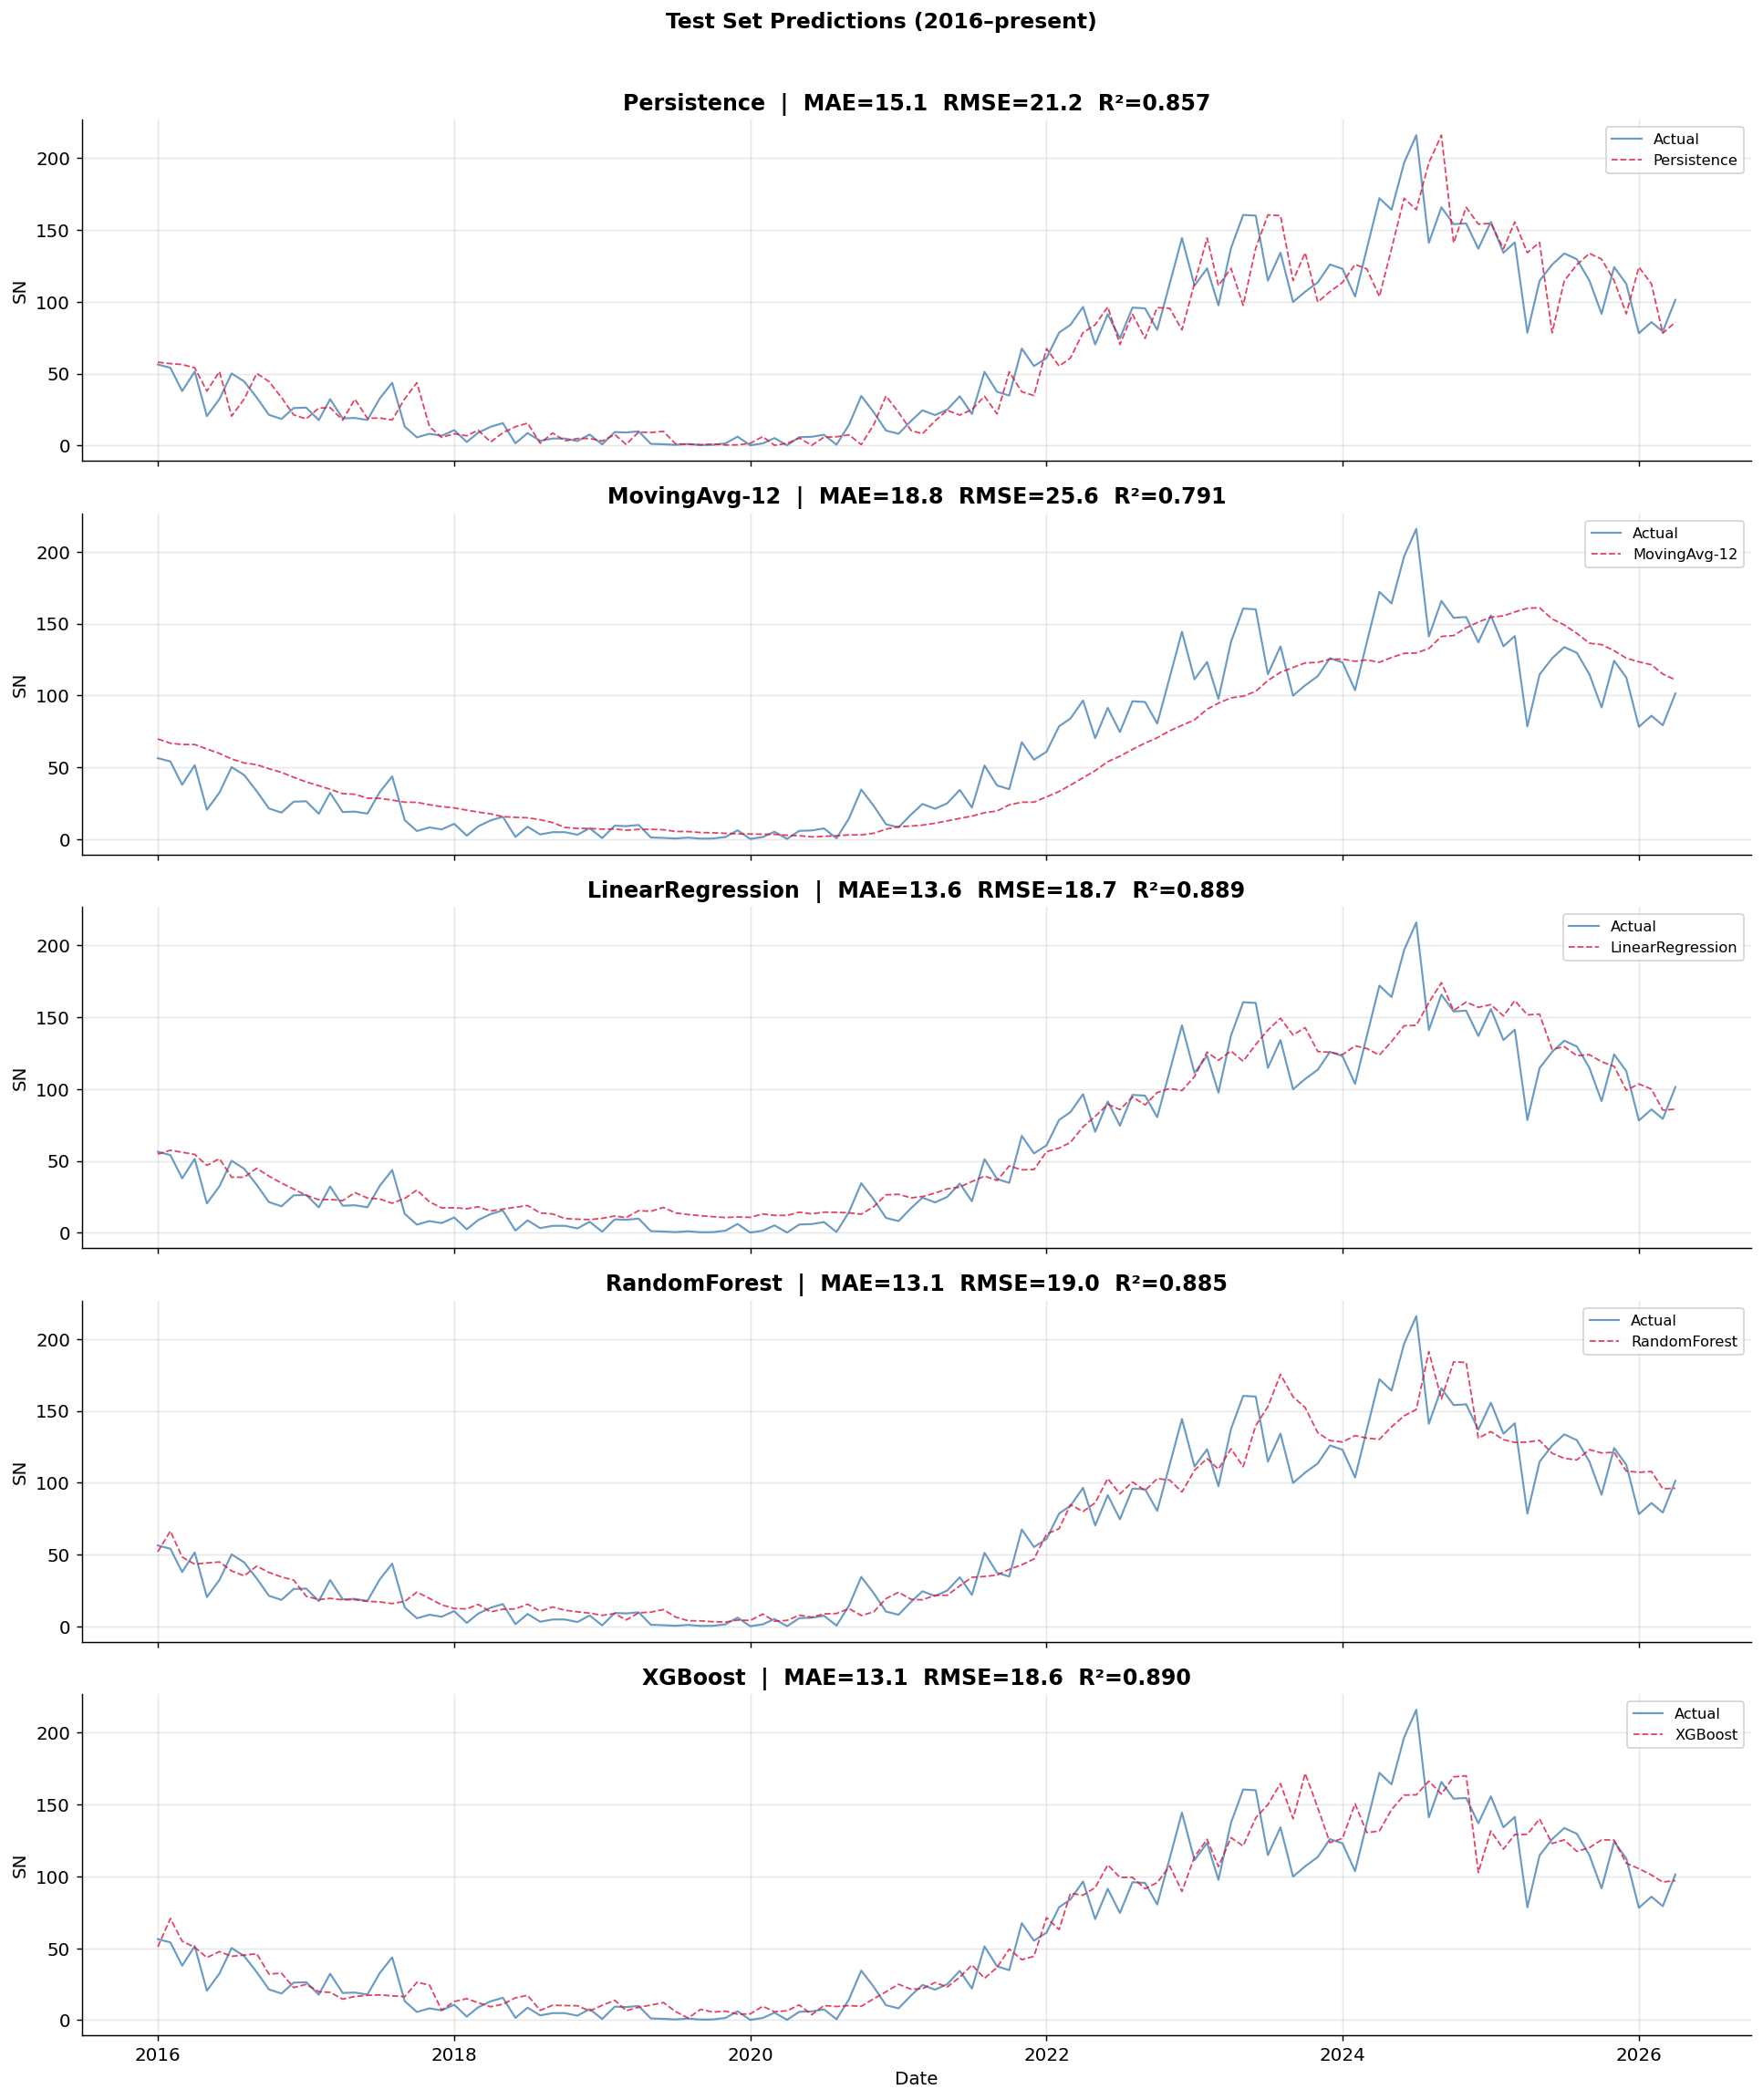

Saved: phase1_predictions.png


In [18]:
# ── Plot 1: Predictions vs Actuals on test set ────────────────────────────────
test_dates = model_df.loc[test_mask, "Date"].values

n_models = len(preds)
fig, axes = plt.subplots(n_models, 1, figsize=(15, 3.5 * n_models), sharex=True)
if n_models == 1:
    axes = [axes]

for ax, (name, (yt, yp)) in zip(axes, preds.items()):
    ax.plot(test_dates, yt, lw=1.2, color="steelblue", label="Actual", alpha=0.8)
    ax.plot(test_dates, yp, lw=1.0, color="crimson",   label=f"{name}", alpha=0.8, linestyle="--")
    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2   = r2_score(yt, yp)
    ax.set_title(f"{name}  |  MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}", fontweight="bold")
    ax.set_ylabel("SN")
    ax.legend(loc="upper right", fontsize=9)

axes[-1].set_xlabel("Date")
plt.suptitle("Test Set Predictions (2016–present)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("phase1_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: phase1_predictions.png")


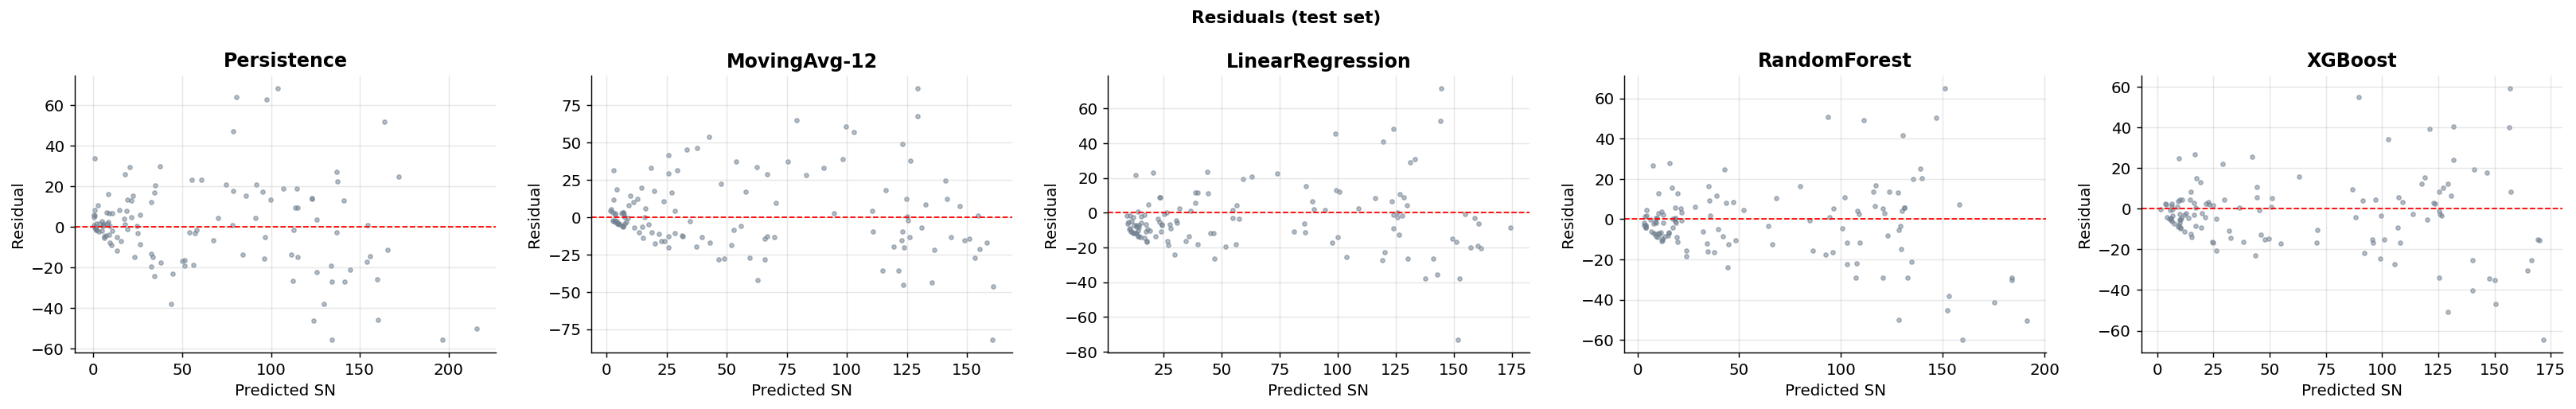

Saved: phase1_residuals.png


In [19]:
# ── Plot 2: Residuals ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, (yt, yp)) in zip(axes, preds.items()):
    resid = yt - yp
    ax.scatter(yp, resid, s=8, alpha=0.5, color="slategray")
    ax.axhline(0, color="red", lw=1, linestyle="--")
    ax.set_xlabel("Predicted SN")
    ax.set_ylabel("Residual")
    ax.set_title(name, fontweight="bold")

plt.suptitle("Residuals (test set)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("phase1_residuals.png", dpi=150)
plt.show()
print("Saved: phase1_residuals.png")


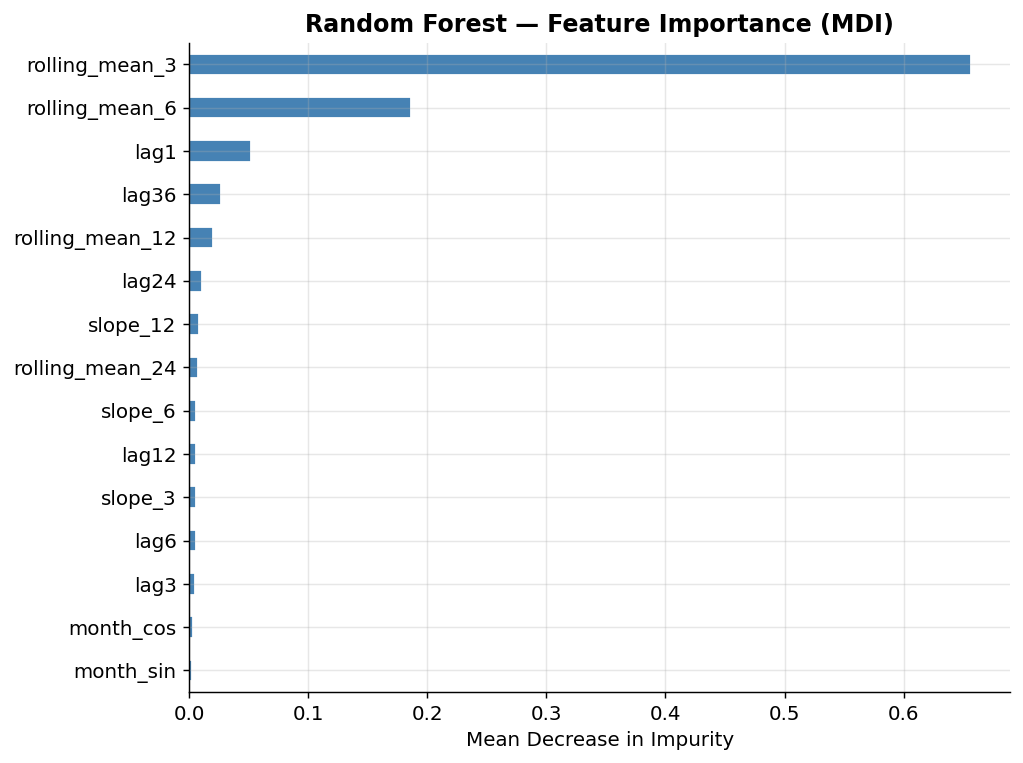

Saved: phase1_feature_importance_rf.png


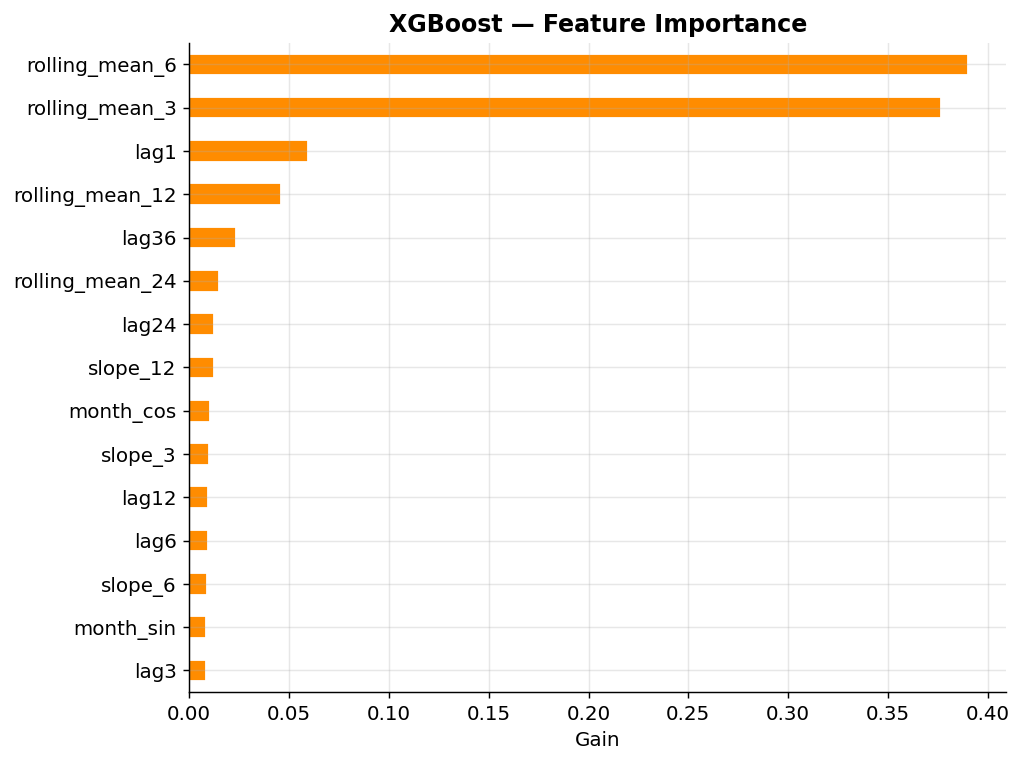

Saved: phase1_feature_importance_xgb.png


In [20]:
# ── Plot 3: Feature importance (Random Forest) ────────────────────────────────
fi = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
fi.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Random Forest — Feature Importance (MDI)", fontweight="bold")
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.savefig("phase1_feature_importance_rf.png", dpi=150)
plt.show()
print("Saved: phase1_feature_importance_rf.png")

if HAS_XGB:
    fi_xgb = pd.Series(best_xgb.feature_importances_, index=feature_cols).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 6))
    fi_xgb.plot(kind="barh", ax=ax, color="darkorange", edgecolor="white")
    ax.set_title("XGBoost — Feature Importance", fontweight="bold")
    ax.set_xlabel("Gain")
    plt.tight_layout()
    plt.savefig("phase1_feature_importance_xgb.png", dpi=150)
    plt.show()
    print("Saved: phase1_feature_importance_xgb.png")


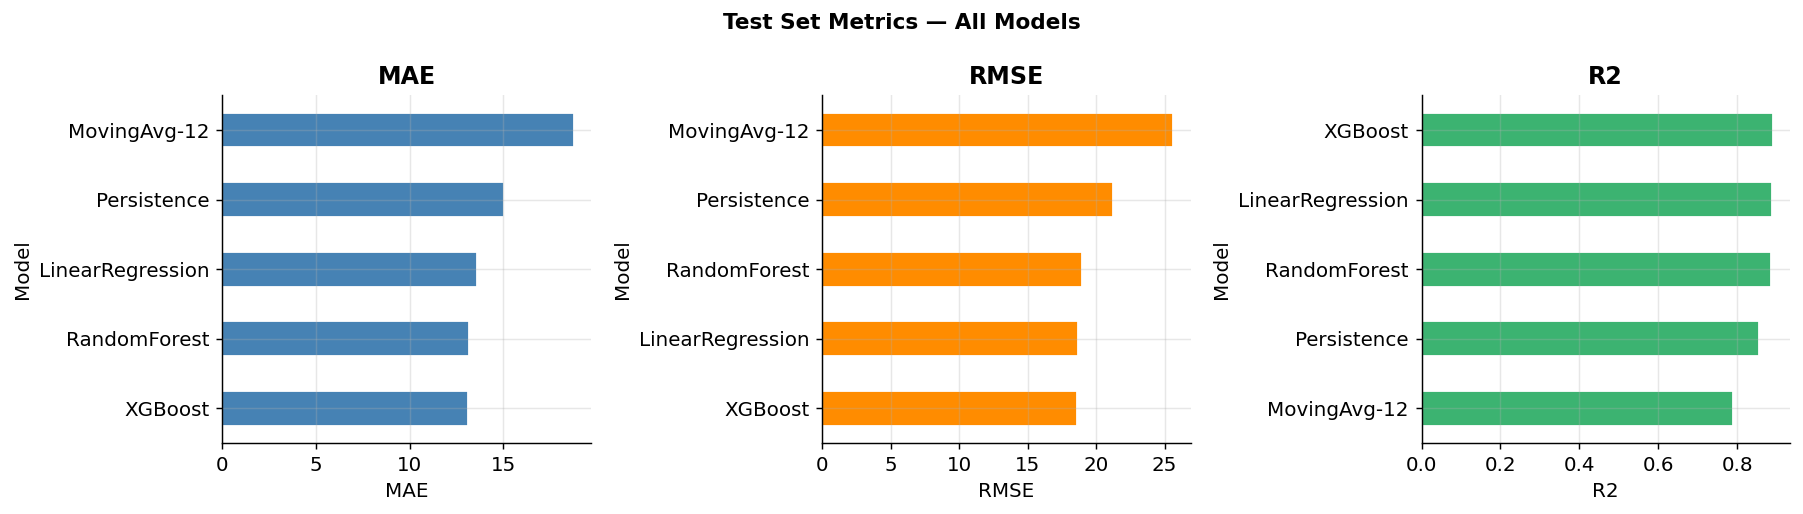

Saved: phase1_metrics_comparison.png


In [21]:
# ── Plot 4: Metric comparison bar chart ───────────────────────────────────────
test_r = results_df[results_df["Model"].str.contains("test")].copy()
test_r["Model"] = test_r["Model"].str.replace(" (test)","",regex=False)
test_r = test_r.set_index("Model")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric, color in zip(axes, ["MAE","RMSE","R2"], ["steelblue","darkorange","mediumseagreen"]):
    test_r[metric].sort_values().plot(kind="barh", ax=ax, color=color, edgecolor="white")
    ax.set_title(metric, fontweight="bold")
    ax.set_xlabel(metric)

plt.suptitle("Test Set Metrics — All Models", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("phase1_metrics_comparison.png", dpi=150)
plt.show()
print("Saved: phase1_metrics_comparison.png")


In [22]:
# ── Save results and best models ──────────────────────────────────────────────
import pickle, os

results_df.to_csv("phase1_results.csv", index=False)
print("Saved: phase1_results.csv")

with open("phase1_best_rf.pkl", "wb") as f:
    pickle.dump(best_rf, f)
print("Saved: phase1_best_rf.pkl")

if HAS_XGB:
    best_xgb.save_model("phase1_best_xgb.json")
    print("Saved: phase1_best_xgb.json")

# Also save the feature list for Phase 2+
with open("phase1_feature_cols.pkl","wb") as f:
    pickle.dump(feature_cols, f)
print("Saved: phase1_feature_cols.pkl")
print()
print("── Summary ─────────────────────────────────────────────────")
best_test = results_df[results_df["Model"].str.contains("test")].sort_values("RMSE").iloc[0]
print(f"Best model on test set : {best_test['Model']}")
print(f"  MAE  = {best_test['MAE']}")
print(f"  RMSE = {best_test['RMSE']}")
print(f"  R²   = {best_test['R2']}")


Saved: phase1_results.csv
Saved: phase1_best_rf.pkl
Saved: phase1_best_xgb.json
Saved: phase1_feature_cols.pkl

── Summary ─────────────────────────────────────────────────
Best model on test set : XGBoost (test)
  MAE  = 13.09
  RMSE = 18.59
  R²   = 0.8896


## Phase 1 Complete ✓

| Output | Description |
|--------|-------------|
| `phase1_results.csv` | MAE / RMSE / R² for all models on val & test |
| `phase1_best_rf.pkl` | Serialised best Random Forest |
| `phase1_best_xgb.json` | Serialised best XGBoost |
| `phase1_feature_cols.pkl` | Feature list for downstream phases |
| `phase1_predictions.png` | Predicted vs actual on test set |
| `phase1_residuals.png` | Residual plots |
| `phase1_feature_importance_rf.png` | RF feature importances |
| `phase1_metrics_comparison.png` | Side-by-side metric bar charts |

**Next:** Phase 2 — Cycle Database Creation
